# 05 — Comparação de modelos (triangulação)

Consolida o `*_metrics.csv` do run **mais recente** de cada modelo × corpus
(LDA, NMF, STM, BERTopic × Folha, Tweets BR 2022) e gera as duas figuras da
página de comparação do site.

## Saídas (`data/output/comparison/`)

- `comparison_metrics.csv` — `corpus, model, run, k, cv, topic_diversity, exclusivity, exclusivity_comparable, coverage`
- `comparison_metrics.png` — barras agrupadas, 1 painel por métrica
- `comparison_coverage_tradeoff.png` — dispersão cobertura × exclusividade

## Ressalvas fixas

- **Exclusividade**: desde o re-run de 2026-08-01 os 8 runs usam
  `compute_exclusivity_ctfidf` sobre a matriz completa (φ/β para LDA/NMF/STM,
  c-TF-IDF para o BERTopic) — todas as células são comparáveis dentro do mesmo
  corpus. A coluna `exclusivity_comparable` e a marca `*` no gráfico seguem no
  código para o caso de a divergência reaparecer.
- **Cobertura**: LDA/NMF/STM atribuem tópico a 100% dos documentos; só o BERTopic
  deixa outliers — é o trade-off que o segundo gráfico isola.
- C_v não é comparável **entre** corpora (vocabulários distintos) — compare dentro
  do mesmo corpus.


In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CORPORA = ["folha", "tweets_bre2022"]
MODELOS = ["lda", "nmf", "stm", "bertopic"]

# Paleta categorica validada (scripts/validate_palette.js da skill dataviz):
# passa lightness, chroma, separacao CVD e piso de visao normal TAMBEM no modo
# all-pairs (exigido pelo scatter). Cor segue o MODELO — nunca o ranking.
CORES = {"lda": "#2a78d6", "nmf": "#eb6834", "stm": "#1baf7a", "bertopic": "#4a3aa7"}
TINTA_TEXTO = "#3d3d3a"      # rotulos usam tinta de texto, nunca a cor da serie


In [2]:
# Consolida o *_metrics.csv do run mais NOVO de cada modelo x corpus
ROWS = []
for corpus in CORPORA:
    for model in MODELOS:
        base = f"../data/output/{corpus}/{model}"
        runs = sorted(glob.glob(f"{base}/{corpus}_2*"))
        path = next((os.path.join(d, f"{model}_metrics.csv")
                     for d in reversed(runs)
                     if os.path.exists(os.path.join(d, f"{model}_metrics.csv"))), None)
        assert path, f"sem {model}_metrics.csv em {base}"
        m = pd.read_csv(path).iloc[0]
        ROWS.append({
            "corpus": corpus, "model": model,
            "run": os.path.basename(os.path.dirname(path)),
            "k": int(m["n_topics"]),
            # LDA/NMF/STM expoem coherence_cv_recomputed; BERTopic grava coherence_cv
            "cv": float(m.get("coherence_cv_recomputed", m.get("coherence_cv", np.nan))),
            "topic_diversity": float(m["topic_diversity_dieng"]),
            # BERTopic: exclusividade c-TF-IDF (matriz completa); demais: phi/beta
            "exclusivity": float(m.get("exclusivity_ctfidf", m.get("exclusivity", np.nan))),
            # Desde 2026-08-01 os 8 runs usam compute_exclusivity_ctfidf; o
            # LDA-tweets era a unica excecao (exclusividade binaria), ja corrigida.
            "exclusivity_comparable": True,
            # LDA/NMF/STM atribuem 100% dos docs; BERTopic deixa outliers
            "coverage": float(m.get("coverage", 1.0)),
        })

comp = pd.DataFrame(ROWS)
os.makedirs("../data/output/comparison", exist_ok=True)
comp.to_csv("../data/output/comparison/comparison_metrics.csv", index=False)
print("Salvo: ../data/output/comparison/comparison_metrics.csv")
comp


Salvo: ../data/output/comparison/comparison_metrics.csv


,corpus,model,run,k,cv,topic_diversity,exclusivity,exclusivity_comparable,coverage
0,folha,lda,folha_20260725_012816,20,0.657491,0.770000,0.457190,True,1.000000
1,folha,nmf,folha_20260723_235727,25,0.653525,0.756000,0.483918,True,1.000000
2,folha,stm,folha_20260724_215748,25,0.679885,0.804000,0.528310,True,1.000000
3,folha,bertopic,folha_20260725_203412,24,0.504029,0.808333,0.491549,True,0.782345
4,tweets_bre2022,lda,tweets_bre2022_20260801_121548,20,0.530154,0.700000,0.507859,True,1.000000
5,tweets_bre2022,nmf,tweets_bre2022_20260723_231011,8,0.559441,0.862500,0.692753,True,1.000000
6,tweets_bre2022,stm,tweets_bre2022_20260725_002913,20,0.587851,0.930000,0.815136,True,1.000000
7,tweets_bre2022,bertopic,tweets_bre2022_20260801_121948,24,0.570007,0.929167,0.777740,True,0.835206


Salvo: ../data/output/comparison/comparison_metrics.png


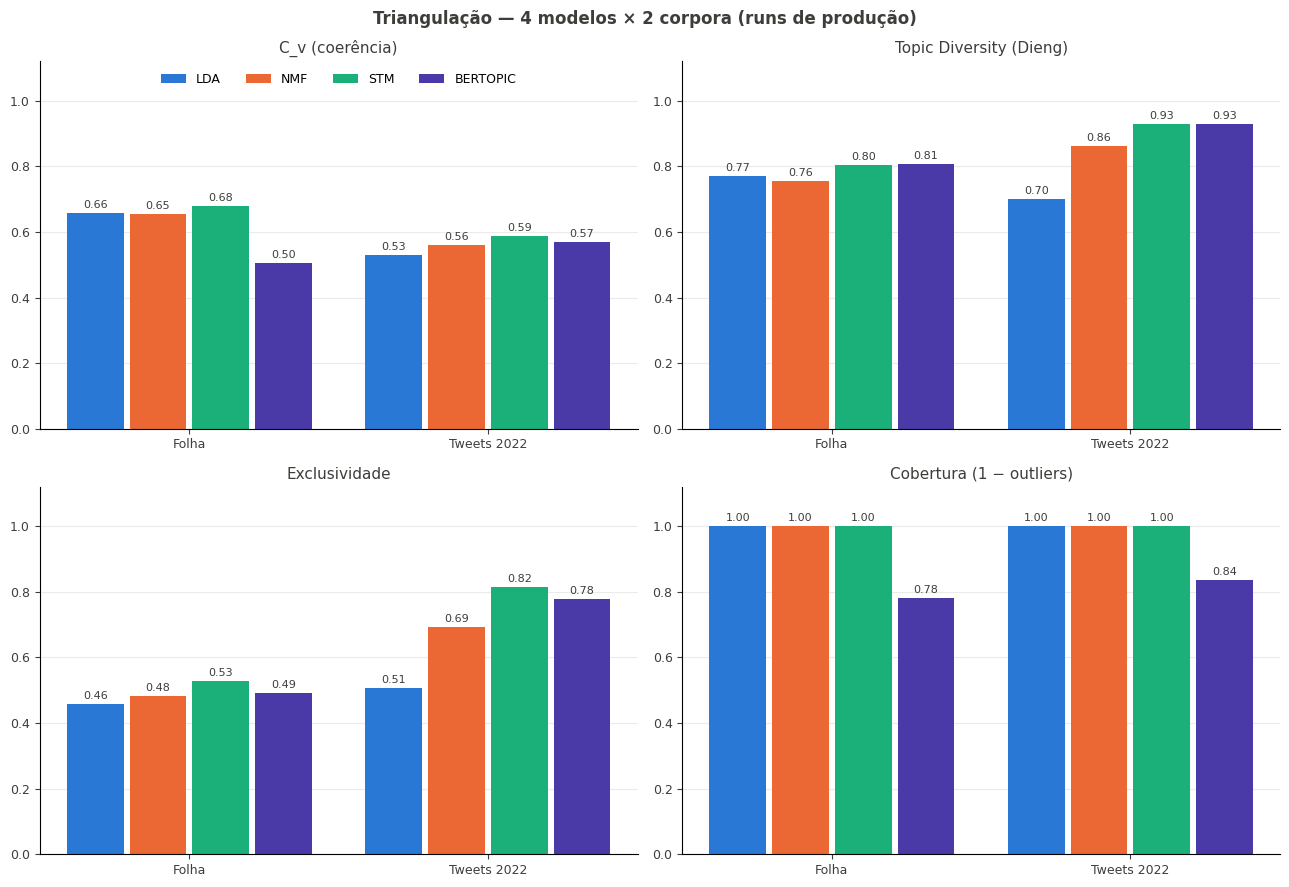

In [3]:
# Barras agrupadas: 1 painel por metrica, modelos lado a lado dentro de cada corpus.
# Escala unica por painel (nunca eixo duplo); rotulo em cada barra atende a ressalva
# de contraste da paleta (relevo por rotulo visivel).
METRICAS = [("cv", "C_v (coerência)"), ("topic_diversity", "Topic Diversity (Dieng)"),
            ("exclusivity", "Exclusividade"), ("coverage", "Cobertura (1 − outliers)")]
ROTULO_CORPUS = {"folha": "Folha", "tweets_bre2022": "Tweets 2022"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
x = np.arange(len(CORPORA))
w = 0.19                      # largura < passo/4 => folga visivel entre as barras

for ax, (col, titulo) in zip(axes.flat, METRICAS):
    for i, mdl in enumerate(MODELOS):
        sub = comp[comp["model"] == mdl].set_index("corpus").reindex(CORPORA)
        pos = x + (i - 1.5) * (w + 0.02)
        barras = ax.bar(pos, sub[col], w, label=mdl.upper(), color=CORES[mdl])
        for b, v, comparavel in zip(barras, sub[col], sub["exclusivity_comparable"]):
            if np.isnan(v):
                continue
            marca = "" if (comparavel or col != "exclusivity") else " *"
            ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}{marca}",
                    ha="center", fontsize=8, color=TINTA_TEXTO)
    ax.set_xticks(x)
    ax.set_xticklabels([ROTULO_CORPUS[c] for c in CORPORA])
    ax.set_title(titulo, fontsize=11, color=TINTA_TEXTO)
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.tick_params(colors=TINTA_TEXTO, labelsize=9)

axes.flat[0].legend(ncols=4, fontsize=9, loc="upper center", frameon=False)
fig.suptitle("Triangulação — 4 modelos × 2 corpora (runs de produção)",
             fontweight="bold", color=TINTA_TEXTO)
if not comp["exclusivity_comparable"].all():
    fig.text(0.01, 0.005,
             "* exclusividade calculada por método distinto — não comparável com as demais células",
             fontsize=8, color=TINTA_TEXTO)
plt.tight_layout()
plt.savefig("../data/output/comparison/comparison_metrics.png", dpi=150,
            bbox_inches="tight", facecolor="white")
print("Salvo: ../data/output/comparison/comparison_metrics.png")
plt.show()


Salvo: ../data/output/comparison/comparison_coverage_tradeoff.png


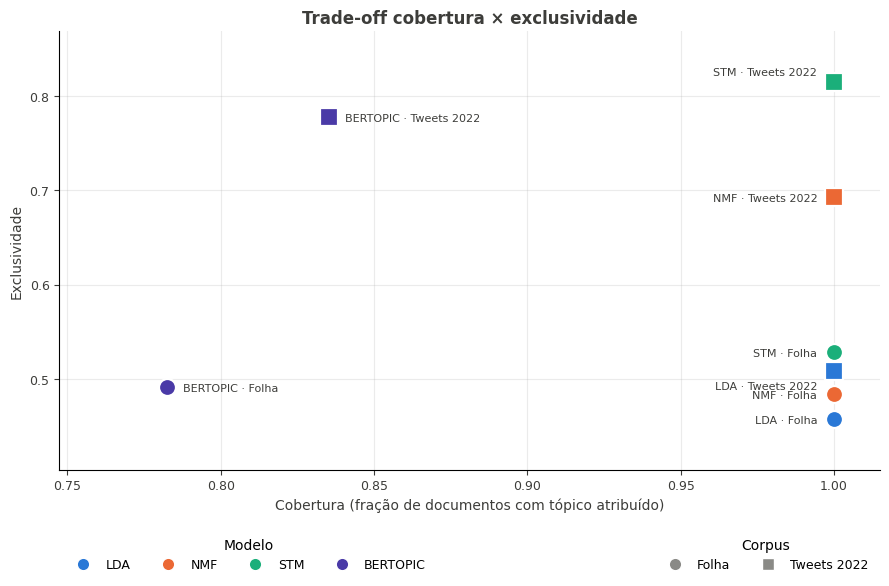

In [4]:
# Trade-off cobertura x exclusividade — o eixo central da triangulacao.
# Identidade dupla: cor = modelo, marcador = corpus; ambos com legenda propria,
# mais rotulo direto em cada ponto (identidade nunca so por cor).
from matplotlib.lines import Line2D

MARCADOR = {"folha": "o", "tweets_bre2022": "s"}
# Deslocamento do rotulo por ponto: LDA/STM-tweets caem quase no mesmo lugar
# (cobertura 1.0, exclusividade ~0.81) — separados na vertical para nao colidir.
DESLOC_Y = {("lda", "tweets_bre2022"): -13, ("stm", "tweets_bre2022"): 5}

fig, ax = plt.subplots(figsize=(9, 6))
for _, r in comp.iterrows():
    ax.scatter(r["coverage"], r["exclusivity"], s=150, marker=MARCADOR[r["corpus"]],
               color=CORES[r["model"]], edgecolors="white", linewidths=1.6, zorder=3)
    # Cobertura e uma fracao: o eixo NAO passa de 1.0 — quem esta no teto recebe
    # o rotulo a esquerda do marcador, em vez de esticar o eixo alem do possivel.
    no_teto = r["coverage"] >= 0.999
    dx, ha = (-12, "right") if no_teto else (12, "left")
    ax.annotate(f"{r['model'].upper()} · {ROTULO_CORPUS[r['corpus']]}",
                (r["coverage"], r["exclusivity"]), textcoords="offset points",
                xytext=(dx, DESLOC_Y.get((r["model"], r["corpus"]), -3)),
                ha=ha, fontsize=8, color=TINTA_TEXTO)

ax.set_xlabel("Cobertura (fração de documentos com tópico atribuído)", color=TINTA_TEXTO)
ax.set_ylabel("Exclusividade", color=TINTA_TEXTO)
ax.set_title("Trade-off cobertura × exclusividade", fontweight="bold", color=TINTA_TEXTO)
ax.grid(alpha=0.25, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.tick_params(colors=TINTA_TEXTO, labelsize=9)
# Folga a direita para os rotulos dos pontos em cobertura = 1.0
ax.set_xlim(comp["coverage"].min() - 0.035, 1.015)
ax.margins(y=0.15)

leg_modelo = [Line2D([], [], marker="o", linestyle="", markersize=9,
                     markerfacecolor=CORES[m], markeredgecolor="white", label=m.upper())
              for m in MODELOS]
leg_corpus = [Line2D([], [], marker=MARCADOR[c], linestyle="", markersize=9,
                     markerfacecolor="#8a8a86", markeredgecolor="white",
                     label=ROTULO_CORPUS[c]) for c in CORPORA]
# Legendas FORA da area de plotagem — dentro elas cobriam os pontos da Folha
primeira = ax.legend(handles=leg_modelo, title="Modelo", ncols=4, fontsize=9,
                     frameon=False, loc="upper left", bbox_to_anchor=(0.0, -0.13))
ax.add_artist(primeira)
ax.legend(handles=leg_corpus, title="Corpus", ncols=2, fontsize=9,
          frameon=False, loc="upper right", bbox_to_anchor=(1.0, -0.13))

plt.tight_layout()
plt.savefig("../data/output/comparison/comparison_coverage_tradeoff.png", dpi=150,
            bbox_inches="tight", facecolor="white")
print("Salvo: ../data/output/comparison/comparison_coverage_tradeoff.png")
plt.show()
